## Notebook 02 — Preprocessing & Feature Extraction
**Project:** Machine Learning for High Performance Optical Sorting
**Author:** Mohamed Tawfeek
**Description:** Image preprocessing, HSV colour histogram extraction, LBP texture feature extraction, and feature serialisation


In [1]:
import os 
import numpy as np
import cv2
from PIL import Image
from skimage.feature import local_binary_pattern
import matplotlib.pyplot as plt

In [2]:
DATASET_PATH = os.path.join('..', 'datasets', 'dataset-resized')
FEATURES_PATH = os.path.join('..', 'results', 'features')
os.makedirs(FEATURES_PATH, exist_ok=True)

CLASSES = ['glass', 'paper', 'cardboard', 'plastic', 'metal', 'trash']

IMAGE_SIZE = (224, 224)
HISTOGRAM_BINS = 32

print("Paths and constants defined")
print(f"Image size: {IMAGE_SIZE}")
print(f"Histogram bins: {HISTOGRAM_BINS}")

Paths and constants defined
Image size: (224, 224)
Histogram bins: 32


In [3]:
# Loads an image from disk, resizes it to the target dimensions, and converts it from RGB to HSV colour space

def preprocess_image(image_path):
    img = Image.open(image_path).convert('RGB')
    img = img.resize(IMAGE_SIZE)
    img_array = np.array(img)
    img_hsv = cv2.cvtColor(img_array, cv2.COLOR_RGB2HSV)
    return img_hsv

print("Preprocessing function defined")

Preprocessing function defined


In [4]:
test_image_path = os.path.join(DATASET_PATH, 'glass', sorted(os.listdir(os.path.join(DATASET_PATH, 'glass')))[0])
test_hsv = preprocess_image(test_image_path)

print(f"Original image path: {test_image_path}")
print(f"Output shape: {test_hsv.shape}")
print(f"Value range - Min: {test_hsv.min()}, Max: {test_hsv.max()}") 

Original image path: ..\datasets\dataset-resized\glass\glass1.jpg
Output shape: (224, 224, 3)
Value range - Min: 0, Max: 242


In [5]:
# Computes a normalised 32-bin histogram for each HSV channel and concatenates them into a 96-dimensional colour feature vector

def extract_colour_histogram(img_hsv):
    features = []
    
    for channel in range(3):
        histogram = cv2.calcHist(
            [img_hsv],
            [channel],
            None,
            [HISTOGRAM_BINS],
            [0, 256]
        )
        histogram = cv2.normalize(histogram, histogram).flatten()
        features.extend(histogram)
    
    return np.array(features)

print("Colour histogram function redefined")
print(f"Expected feature vector length: {3 * HISTOGRAM_BINS}")

Colour histogram function redefined
Expected feature vector length: 96


In [6]:
test_histogram = extract_colour_histogram(test_hsv)

print(f"Feature vector shape: {test_histogram.shape}")
print(f"Frist 10 values: {test_histogram[:10].round(3)}")

Feature vector shape: (96,)
Frist 10 values: [0.27  0.402 0.479 0.621 0.387 0.003 0.    0.    0.    0.   ]


In [7]:
# Computes a uniform LBP texture descriptor on the greyscale image and returns a 26-bin normalised density histogram

def extract_lbp_features(img_hsv):
    img_gray = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2BGR)
    img_gray = cv2.cvtColor(img_gray, cv2.COLOR_BGR2GRAY)

    radius = 3
    n_points = 8*radius

    lbp = local_binary_pattern(img_gray, n_points, radius, method='uniform')

    n_bins = n_points+2
    histogram, _ = np.histogram(lbp, bins=n_bins, range =(0,n_bins), density=True)

    return histogram

print("LBP func defined")
print(f"expected lbp feautre vector length : {8*3+2}")

LBP func defined
expected lbp feautre vector length : 26


In [8]:
test_lbp = extract_lbp_features(test_hsv)

print(f"LBP feature vector shape: {test_lbp.shape}")
print(f"First 10 values: {test_lbp[:10].round(3)}")
print(f"Total features so far: {test_histogram.shape[0] + test_lbp.shape[0]}")

LBP feature vector shape: (26,)
First 10 values: [0.008 0.005 0.005 0.009 0.004 0.005 0.004 0.012 0.017 0.02 ]
Total features so far: 122


In [9]:
# Combines HSV colour and LBP texture features into a single 122-dimensional feature vector

def extract_features(image_path):
    img_hsv = preprocess_image(image_path)
    colour_features = extract_colour_histogram(img_hsv)
    lbp_features = extract_lbp_features(img_hsv)
    combined_features = np.concatenate([colour_features, lbp_features])
    return combined_features

test_features = extract_features(test_image_path)
print(f"combined feature vector shape: {test_features.shape}")

combined feature vector shape: (122,)


In [10]:
# Iterates over all class folders, extracts features from every image, and assembles the full feature matrix and label array

print("EXTRACTING FEATURES FROM ALL IMAGES")

all_features = []
all_labels = []

for class_name in CLASSES:
    class_folder = os.path.join(DATASET_PATH, class_name)
    image_files = sorted([f for f in os.listdir(class_folder) if f.endswith('.jpg')])

    for filename in image_files:
        image_path = os.path.join(class_folder, filename)
        features = extract_features(image_path)
        all_features.append(features)
        all_labels.append(class_name)

    print(f"{class_name}: {len(image_files)} images processed")

all_features = np.array(all_features)
all_labels = np.array(all_labels)
print(f"Feature matrix shape: {all_features.shape}")
print(f"Labels array shape: {all_labels.shape}")

EXTRACTING FEATURES FROM ALL IMAGES


glass: 501 images processed


paper: 594 images processed


cardboard: 403 images processed


plastic: 482 images processed


metal: 410 images processed


trash: 137 images processed
Feature matrix shape: (2527, 122)
Labels array shape: (2527,)


In [11]:
print(all_labels[:10])
print(all_labels[-10:])

['glass' 'glass' 'glass' 'glass' 'glass' 'glass' 'glass' 'glass' 'glass'
 'glass']
['trash' 'trash' 'trash' 'trash' 'trash' 'trash' 'trash' 'trash' 'trash'
 'trash']


In [12]:
print(all_labels[490:510])

['glass' 'glass' 'glass' 'glass' 'glass' 'glass' 'glass' 'glass' 'glass'
 'glass' 'glass' 'paper' 'paper' 'paper' 'paper' 'paper' 'paper' 'paper'
 'paper' 'paper']


In [13]:
np.save(os.path.join(FEATURES_PATH, 'features.npy'), all_features)
np.save(os.path.join(FEATURES_PATH, 'labels.npy'), all_labels)

print("Features saved successfully")
print(f"Saved to: {FEATURES_PATH}")

Features saved successfully
Saved to: ..\results\features


In [14]:
loaded_features = np.load(os.path.join(FEATURES_PATH, 'features.npy'))
loaded_labels = np.load(os.path.join(FEATURES_PATH, 'labels.npy'))

print(f"Loaded features shape: {loaded_features.shape}")
print(f"Loaded labels shape: {loaded_labels.shape}")
print(f"First label: {loaded_labels[0]}")
print(f"First feature vector (first 5 values): {loaded_features[0][:5].round(3)}")

Loaded features shape: (2527, 122)
Loaded labels shape: (2527,)
First label: glass
First feature vector (first 5 values): [0.27  0.402 0.479 0.621 0.387]


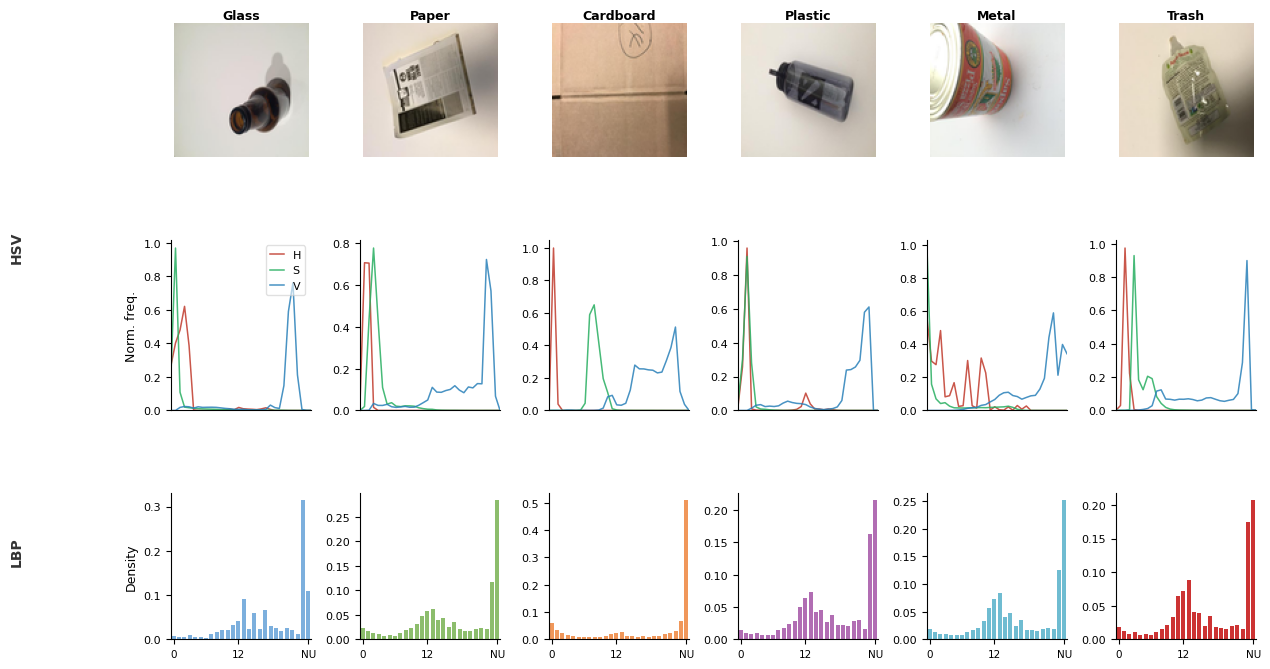

Saved: feature_examples.png


In [15]:
# Generates a per-class panel showing a sample thumbnail alongside its HSV histogram and LBP histogram for visual inspection of the extracted features

FIGURES_PATH = os.path.join('..', 'results', 'figures')

CLASS_COLORS = {
    'glass': '#5b9bd5', 'paper': '#70ad47', 'cardboard': '#ed7d31',
    'plastic': '#9e48a0', 'metal': '#4bacc6', 'trash': '#c00000',
}
CHANNEL_COLORS = ['#c0392b', '#27ae60', '#2980b9']
CHANNEL_LABELS = ['H', 'S', 'V']

import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 8))
fig.patch.set_facecolor('white')
outer = gridspec.GridSpec(3, 6, figure=fig, hspace=0.55, wspace=0.35,
                          height_ratios=[1.1, 1.4, 1.2])

for c, cls in enumerate(CLASSES):
    folder = os.path.join(DATASET_PATH, cls)
    img_path = os.path.join(folder, sorted(os.listdir(folder))[0])
    pil_img = Image.open(img_path).convert('RGB')
    img_hsv = preprocess_image(img_path)
    colour_feats = extract_colour_histogram(img_hsv)
    lbp_feats    = extract_lbp_features(img_hsv)

    H = colour_feats[0:32]
    S = colour_feats[32:64]
    V = colour_feats[64:96]

    ax_img = fig.add_subplot(outer[0, c])
    ax_img.imshow(pil_img.resize((100, 100), Image.LANCZOS))
    ax_img.axis('off')
    ax_img.set_title(cls.capitalize(), fontsize=9, fontweight='bold', pad=3)

    ax_hsv = fig.add_subplot(outer[1, c])
    x = np.arange(HISTOGRAM_BINS)
    for ch_hist, ch_color, ch_label in zip([H, S, V], CHANNEL_COLORS, CHANNEL_LABELS):
        ax_hsv.plot(x, ch_hist, color=ch_color, linewidth=1.1, alpha=0.85, label=ch_label)
    ax_hsv.set_xlim(0, HISTOGRAM_BINS - 1)
    ax_hsv.set_ylim(bottom=0)
    ax_hsv.set_xticks([])
    ax_hsv.tick_params(axis='y', labelsize=8)
    ax_hsv.spines[['top', 'right']].set_visible(False)
    if c == 0:
        ax_hsv.set_ylabel('Norm. freq.', fontsize=9)
        ax_hsv.legend(fontsize=8, loc='upper right', framealpha=0.6, handlelength=1.2)

    ax_lbp = fig.add_subplot(outer[2, c])
    ax_lbp.bar(np.arange(len(lbp_feats)), lbp_feats,
               color=CLASS_COLORS[cls], alpha=0.8, width=0.75)
    ax_lbp.set_xlim(-0.5, len(lbp_feats) - 0.5)
    ax_lbp.set_ylim(bottom=0)
    ax_lbp.set_xticks([0, 12, 25])
    ax_lbp.set_xticklabels(['0', '12', 'NU'], fontsize=7.5)
    ax_lbp.tick_params(axis='y', labelsize=8)
    ax_lbp.spines[['top', 'right']].set_visible(False)
    if c == 0:
        ax_lbp.set_ylabel('Density', fontsize=9)

fig.text(0.01, 0.60, 'HSV', va='center', ha='left',
         fontsize=10, fontweight='bold', color='#333333', rotation=90)
fig.text(0.01, 0.22, 'LBP', va='center', ha='left',
         fontsize=10, fontweight='bold', color='#333333', rotation=90)

plt.savefig(os.path.join(FIGURES_PATH, 'feature_examples.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: feature_examples.png")

In [16]:
# Verifies that src/features.py reproduces this notebook's feature pipeline exactly.
# The evaluation notebooks (06, 07, 12, 13, demo) import from that module, so this
# assertion is what guarantees training and evaluation share one feature space.

import sys
sys.path.insert(0, os.path.abspath('..'))
from src import features as F

sample_paths = [F.list_class_images(DATASET_PATH, c)[0] for c in CLASSES]
max_diff = max(
    np.abs(extract_features(p) - F.extract_features(p)).max()
    for p in sample_paths
)

assert max_diff == 0.0, f"src/features.py diverges from notebook 02 (max diff {max_diff})"
print(f"src/features.py matches this notebook exactly (max abs difference: {max_diff})")


src/features.py matches this notebook exactly (max abs difference: 0.0)
